In [131]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2_contingency
from scipy.stats.contingency import association
import statsmodels.api as sm

%matplotlib inline

In [2]:
df = pd.read_csv("/Users/k.yukhlina/IronHack/Week_5/Day_1/amz_uk_price_prediction_dataset.csv")
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [3]:
df.shape

(2443651, 9)

In [4]:
df.dtypes

uid                    int64
asin                     str
title                    str
stars                float64
reviews                int64
price                float64
isBestSeller            bool
boughtInLastMonth      int64
category                 str
dtype: object

In [5]:
list(set(df.dtypes.tolist()))

[dtype('float64'),
 dtype('int64'),
 dtype('bool'),
 <StringDtype(storage='python', na_value=nan)>]

In [6]:
df.select_dtypes("number").columns

Index(['uid', 'stars', 'reviews', 'price', 'boughtInLastMonth'], dtype='str')

In [7]:
df.select_dtypes("object").columns

/var/folders/1q/2t5621cd5kz7blvfr_nw9dl80000gn/T/ipykernel_1506/3881633646.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes("object").columns


Index(['asin', 'title', 'category'], dtype='str')

In [8]:
df.select_dtypes("object").nunique().sort_values(ascending=False)

/var/folders/1q/2t5621cd5kz7blvfr_nw9dl80000gn/T/ipykernel_1506/3982989784.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes("object").nunique().sort_values(ascending=False)


asin        2222742
title       2077591
category        296
dtype: int64

In [9]:
df.isnull().sum().sort_values(ascending=False)

uid                  0
asin                 0
title                0
stars                0
reviews              0
price                0
isBestSeller         0
boughtInLastMonth    0
category             0
dtype: int64

In [10]:
df.drop("uid", inplace=True, axis=1)

## Part 1: Analyzing Best-Seller Trends Across Product Categories

**Objective:** Understand the relationship between product categories and their best-seller status.

**1. Crosstab Analysis:**

- Create a crosstab between the product category and the isBestSeller status.
- Are there categories where being a best-seller is more prevalent?

*Hint: one option is to calculate the proportion of best-sellers for each category and then sort the categories based on this proportion in descending order.*

In [11]:
df["isBestSeller"] = df["isBestSeller"].replace(False, "notTheBest")
df["isBestSeller"] = df["isBestSeller"].replace(True, "theBest")

In [12]:
crosstable = pd.crosstab(df["category"], columns = [df["isBestSeller"]])
crosstable


isBestSeller,notTheBest,theBest
category,,
3D Printers,247,1
3D Printing & Scanning,4065,2
Abrasive & Finishing Products,245,5
Action Cameras,1696,1
Adapters,251,3
...,...,...
Wind Instruments,243,7
Window Treatments,234,5
Women,17559,213


In [13]:
crosstable_for_sort = crosstable.copy()
crosstable_for_sort["proportion"] = (crosstable["theBest"] / (crosstable["theBest"]+crosstable["notTheBest"]))*100
crosstable_for_sort["proportion"]

category
3D Printers                       0.403226
3D Printing & Scanning            0.049176
Abrasive & Finishing Products     2.000000
Action Cameras                    0.058928
Adapters                          1.181102
                                    ...   
Wind Instruments                  2.800000
Window Treatments                 2.092050
Women                             1.198515
Women's Sports & Outdoor Shoes    1.020929
eBook Readers & Accessories       0.000000
Name: proportion, Length: 296, dtype: float64

In [14]:
crosstable_for_sort = crosstable_for_sort.sort_values(by="proportion", ascending=False)
crosstable_for_sort = crosstable_for_sort[crosstable_for_sort["proportion"] >= 1]
crosstable_for_sort

isBestSeller,notTheBest,theBest,proportion
category,,,
Grocery,9008,556,5.813467
Smart Home Security & Lighting,98,6,5.769231
Health & Personal Care,9017,552,5.768628
Mobile Phone Accessories,248,11,4.247104
Power & Hand Tools,8353,306,3.533895
"Billiard, Snooker & Pool",241,8,3.212851
Pet Supplies,9152,285,3.020028
Home Brewing & Wine Making,239,7,2.845528
Wind Instruments,243,7,2.800000


In [15]:
sorted_crosstable = crosstable_for_sort
sorted_crosstable.drop("proportion", inplace=True, axis=1)
sorted_crosstable

isBestSeller,notTheBest,theBest
category,,
Grocery,9008,556
Smart Home Security & Lighting,98,6
Health & Personal Care,9017,552
Mobile Phone Accessories,248,11
Power & Hand Tools,8353,306
"Billiard, Snooker & Pool",241,8
Pet Supplies,9152,285
Home Brewing & Wine Making,239,7
Wind Instruments,243,7


**Conclusion.**
The best-seller categories can be filtered by ''df["category"][df["isBestSeller"] == True]'' becuase we need to get the category names only with isBestSeller = True. Than we need to get number of True values from isBestSeller column.

In the result we have top-10 best-seller categories.


**2. Statistical Tests:**

- Conduct a Chi-square test to determine if the best-seller distribution is independent of the product category.
- Compute Cramér's V to understand the strength of association between best-seller status and category.

In [16]:
chi2, p_value, _, expected_f = chi2_contingency(sorted_crosstable)

In [17]:
if(p_value < 0.05):
    print(f"Conclusion. There is a significant association between the categorical variables, p_value = {p_value}. Chi-square is big enough to decliny H0, chi-square = {chi2}")
elif(p_value >= 0.05):
    print(f"Conclusion. There is not enough evidence to conclude a significant association between the variables, p_value = {p_value}. Chi-square is not big enough to decliny H0, chi-square = {chi2}")

Conclusion. There is a significant association between the categorical variables, p_value = 6.051285561087437e-286. Chi-square is big enough to decliny H0, chi-square = 1529.5152505638061


In [18]:
cramer_v = association(sorted_crosstable, method="cramer")

In [19]:
if(cramer_v > 0.0 and cramer_v < 0.1):
    print("For full crosstable calculations of Cramér's V shows very poor relationship between columns")
elif(cramer_v > 0.1 and cramer_v < 0.3):
    print("For full crosstable calculations of Cramér's V shows poor relationship between columns")
elif(cramer_v > 0.3 and cramer_v < 0.5):
    print("For full crosstable calculations of Cramér's V shows medium relationship between columns")
elif(cramer_v > 0.5):
    print("For full crosstable calculations of Cramér's V shows strong relationship between columns") 

For full crosstable calculations of Cramér's V shows very poor relationship between columns


**3. Visualizations:**

- Visualize the relationship between product categories and the best-seller status using a stacked bar chart.

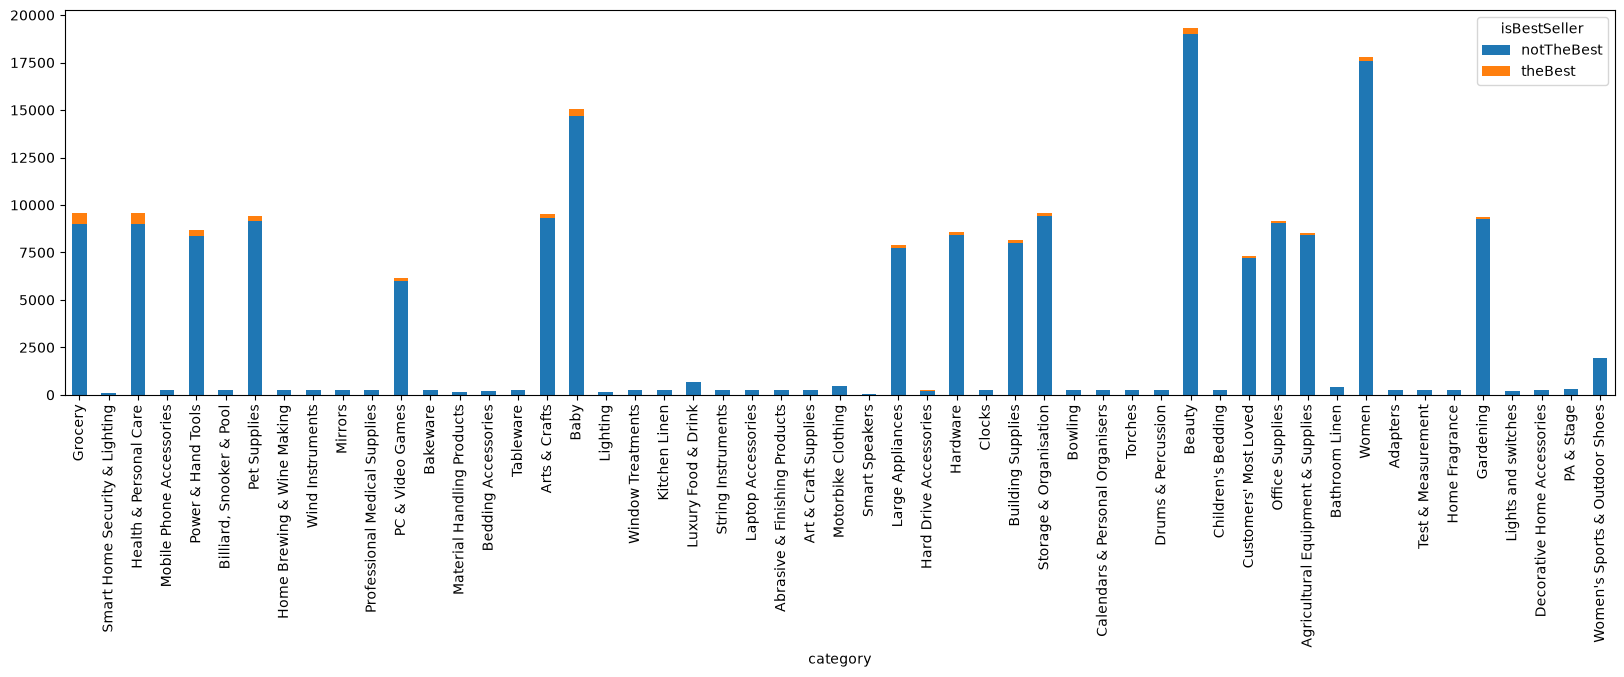

In [20]:
sorted_crosstable.plot( kind="bar", stacked=True, figsize=(20, 5));

**Conclusion**
Scatter

## Part 2: Exploring Product Prices and Ratings Across Categories and Brands

**Objective:** Investigate how different product categories influence product prices.

**0. Preliminary Step:** Remove outliers in product prices.

For this purpose, we can use the IQR (Interquartile Range) method. Products priced below the first quartile minus 1.5 times the IQR or above the third quartile plus 1.5 times the IQR will be considered outliers and removed from the dataset. The next steps will be done with the dataframe without outliers.

*Hint: you can check the last Check For Understanding at the end of the lesson EDA Bivariate Analysis for a hint on how to do this.*

In [21]:
df.price.describe()

count    2.443651e+06
mean     8.924381e+01
std      3.456089e+02
min      0.000000e+00
25%      9.990000e+00
50%      1.909000e+01
75%      4.599000e+01
max      1.000000e+05
Name: price, dtype: float64

In [24]:
def tukeys_test_outliers (column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower_wisker = Q1 - 1.5 * IQR
    upper_wisker = Q3 + 1.5 * IQR
    outliers = column[(column < lower_wisker) | (column > upper_wisker)]

    return outliers

In [26]:
data_for_check = df["price"]
outliers = tukeys_test_outliers(data_for_check)
print(outliers)

10         139.00
19         164.99
25         149.99
28         289.00
31         199.99
            ...  
2443619    166.99
2443627    152.58
2443638    108.77
2443641    166.99
2443643    158.99
Name: price, Length: 327688, dtype: float64


In [28]:
filtered_price = df.iloc[~outliers.index,:]

**1. Violin Plots:**

- Use a violin plot to visualize the distribution of price across different product categories. Filter out the top 20 categories based on count for better visualization.
- Which product category tends to have the highest median price? Don't filter here by top categories.

In [97]:
df_best_selled_categories = filtered_price[(filtered_price["category"].isin(sorted_crosstable.index))]
list_top_category = df_best_selled_categories["category"].value_counts().head(20).index
list_top_category

Index(['Grocery', 'Customers' Most Loved', 'Baby', 'Hardware', 'Pet Supplies',
       'PC & Video Games', 'Office Supplies', 'Gardening', 'Beauty',
       'Building Supplies', 'Agricultural Equipment & Supplies',
       'Power & Hand Tools', 'Arts & Crafts', 'Luxury Food & Drink',
       'Calendars & Personal Organisers', 'Health & Personal Care',
       'Mobile Phone Accessories', 'Tableware', 'Women', 'Motorbike Clothing'],
      dtype='str', name='category')

In [95]:
df_best_selled_categories

,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
2443640,B0BX2KM9KQ,Motorcycle Socks 2 Pairs I'd Rather be on My M...,0.0,0,10.99,notTheBest,0,Motorbike Clothing
2443631,B01N1GW57Z,WULFSPORT LINEAR MOTORBIKE KIDS RACE SUIT New ...,5.0,4,60.62,notTheBest,0,Motorbike Clothing
2443625,B095K5HFZ7,SHIMA SX-2 EVO LADY Motorbike Shoes for Women ...,4.6,170,99.95,notTheBest,0,Motorbike Clothing
2443622,6040458925,starlingukpk Quality Flexible Motorbike Motorc...,4.2,2,9.99,notTheBest,0,Motorbike Clothing
2443619,B07JLZB7YY,Motorcycle Clothing Suit - Motorbike Suit With...,0.0,0,166.99,notTheBest,0,Motorbike Clothing
...,...,...,...,...,...,...,...,...
18527,B07QHZZ34W,Jet Motorcycle Motorbike Jacket Mens Textile W...,4.5,418,59.99,notTheBest,0,Motorbike Clothing
18526,B09PD3FLZC,"COFIT Microfiber Leather Motorcycle Gloves, To...",4.3,6518,19.99,notTheBest,0,Motorbike Clothing
18525,B017UKP6W4,VIPER MOTO Accessories Braces,4.5,395,14.99,notTheBest,0,Motorbike Clothing
18524,B0B8DGVVQZ,ROTTO Balaclava Face Mask Ski Mask Winter Pola...,4.4,249,13.99,notTheBest,0,Motorbike Clothing


In [98]:
plot_df = df_best_selled_categories[df_best_selled_categories["category"].isin(list_top_category)]
plot_df

,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
2443640,B0BX2KM9KQ,Motorcycle Socks 2 Pairs I'd Rather be on My M...,0.0,0,10.99,notTheBest,0,Motorbike Clothing
2443631,B01N1GW57Z,WULFSPORT LINEAR MOTORBIKE KIDS RACE SUIT New ...,5.0,4,60.62,notTheBest,0,Motorbike Clothing
2443625,B095K5HFZ7,SHIMA SX-2 EVO LADY Motorbike Shoes for Women ...,4.6,170,99.95,notTheBest,0,Motorbike Clothing
2443622,6040458925,starlingukpk Quality Flexible Motorbike Motorc...,4.2,2,9.99,notTheBest,0,Motorbike Clothing
2443619,B07JLZB7YY,Motorcycle Clothing Suit - Motorbike Suit With...,0.0,0,166.99,notTheBest,0,Motorbike Clothing
...,...,...,...,...,...,...,...,...
18527,B07QHZZ34W,Jet Motorcycle Motorbike Jacket Mens Textile W...,4.5,418,59.99,notTheBest,0,Motorbike Clothing
18526,B09PD3FLZC,"COFIT Microfiber Leather Motorcycle Gloves, To...",4.3,6518,19.99,notTheBest,0,Motorbike Clothing
18525,B017UKP6W4,VIPER MOTO Accessories Braces,4.5,395,14.99,notTheBest,0,Motorbike Clothing
18524,B0B8DGVVQZ,ROTTO Balaclava Face Mask Ski Mask Winter Pola...,4.4,249,13.99,notTheBest,0,Motorbike Clothing


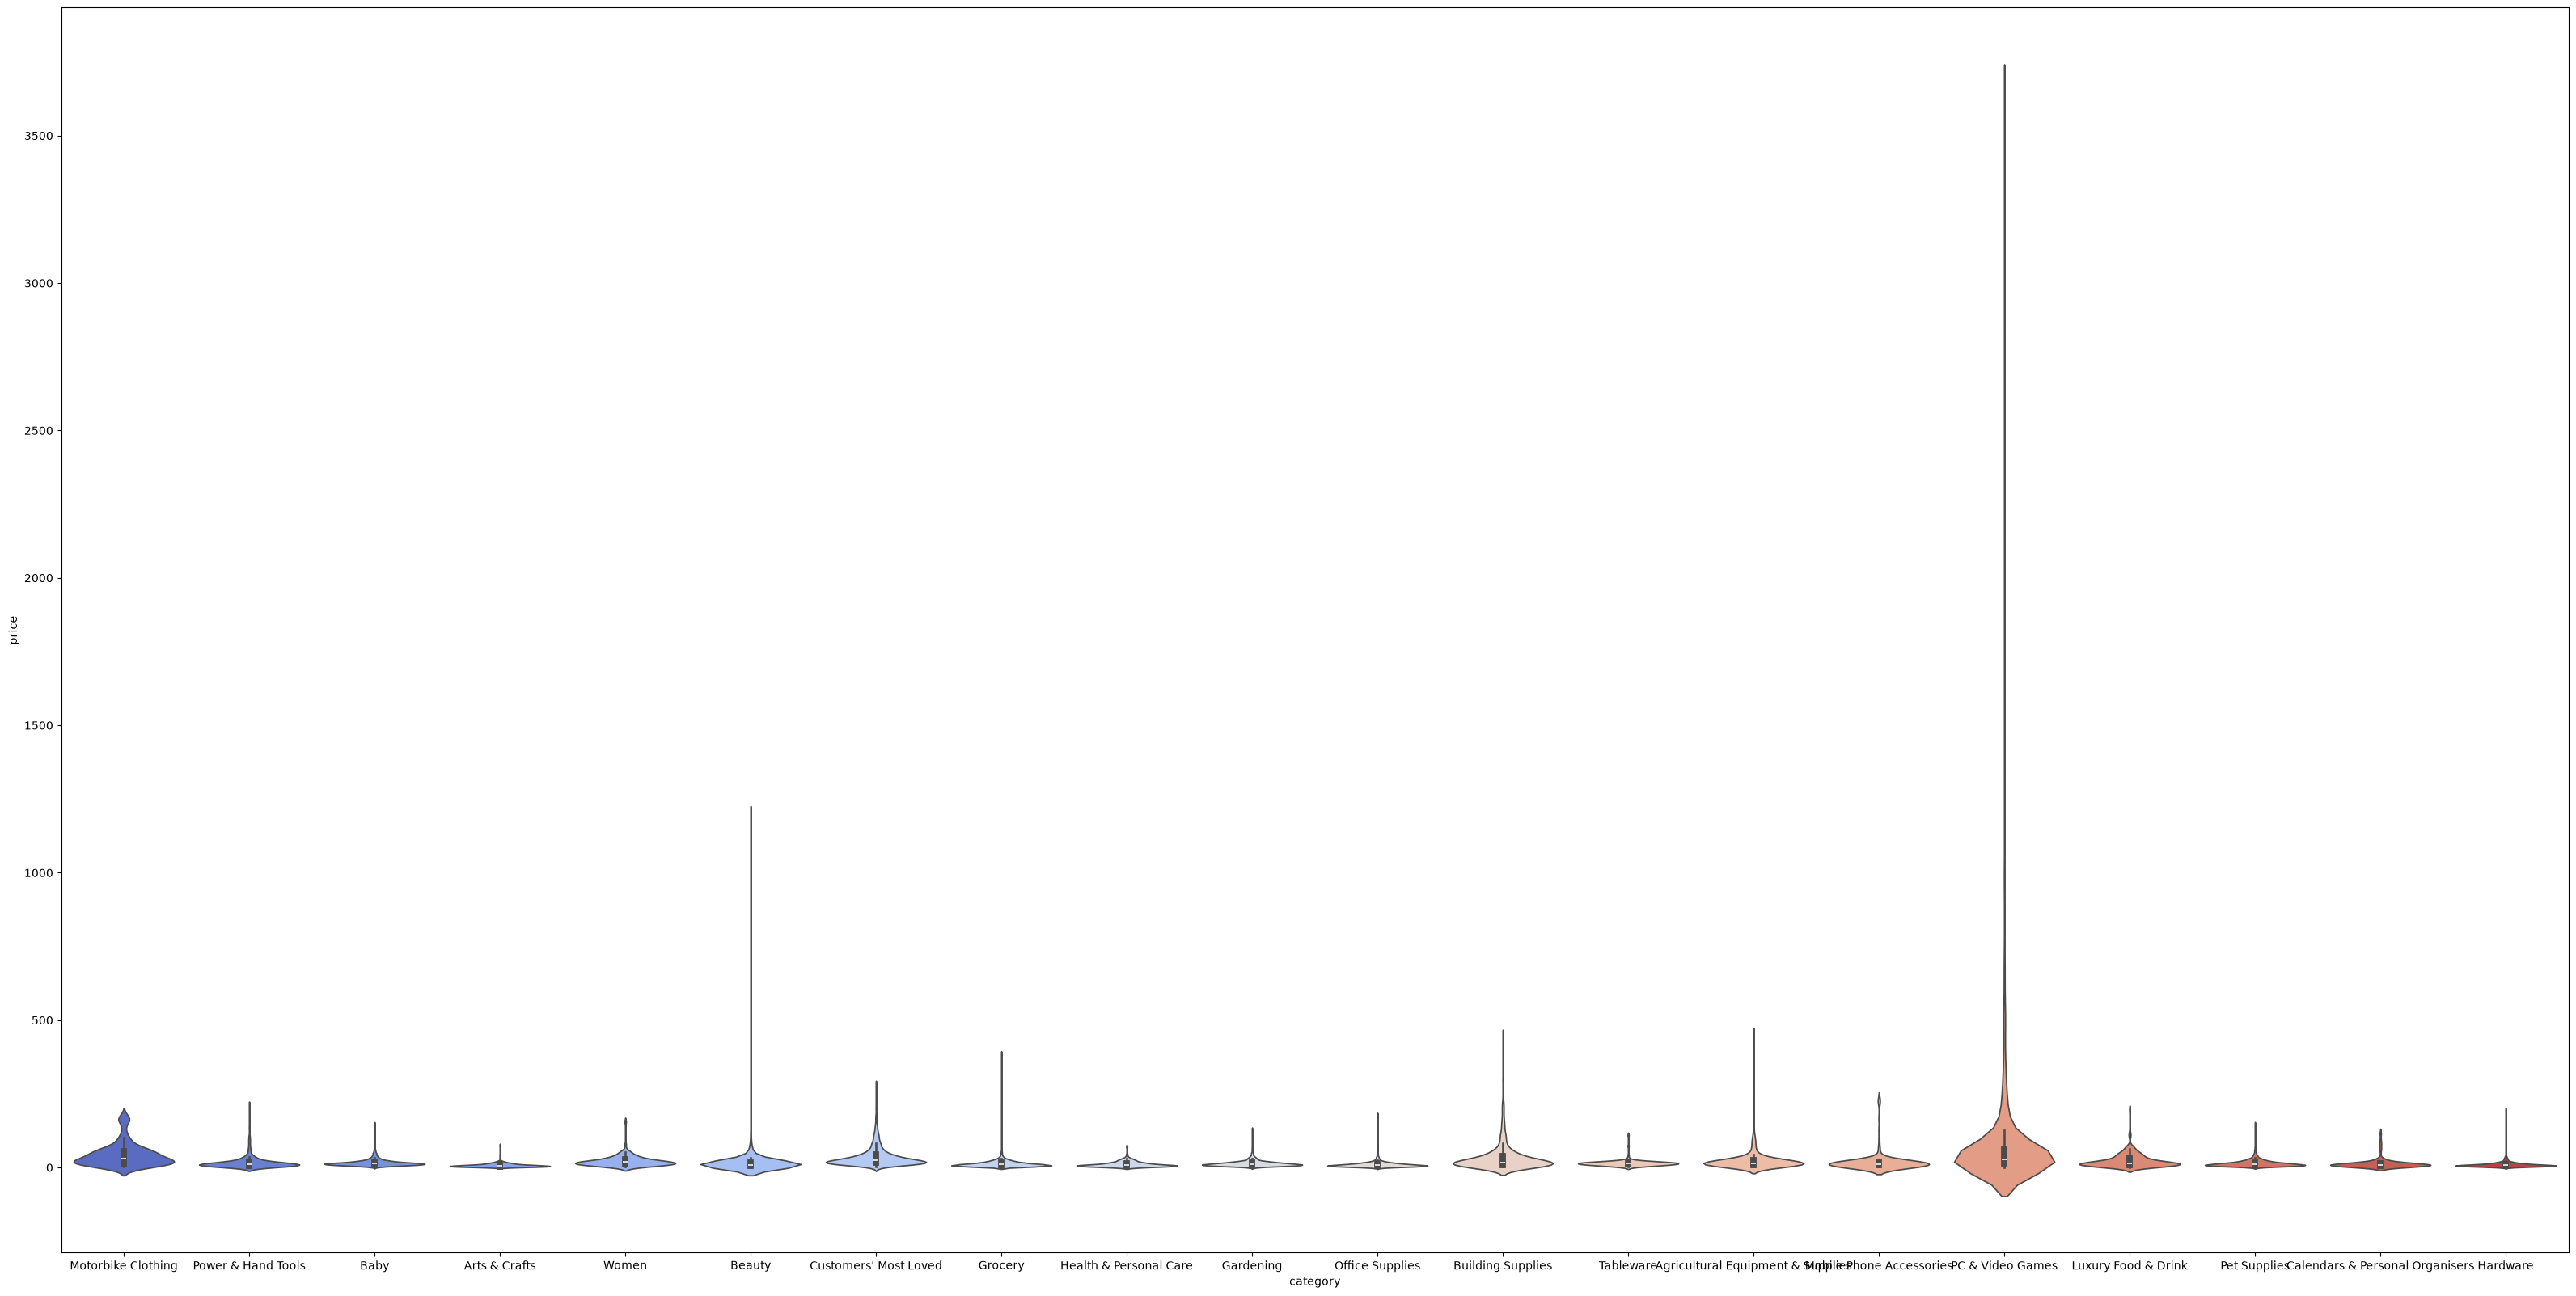

In [103]:
plt.figure(figsize=(40, 20))
sns.violinplot(data=plot_df, x='category', y='price', palette="coolwarm", hue='category', legend=False);

**2. Bar Charts:**

- Create a bar chart comparing the average price of products for the top 10 product categories (based on count).
- Which product category commands the highest average price? Don't filter here by top categories.

In [107]:
top_10_categories = df_best_selled_categories["category"].value_counts().head(10).index
top_10_categories

Index(['Grocery', 'Customers' Most Loved', 'Baby', 'Hardware', 'Pet Supplies',
       'PC & Video Games', 'Office Supplies', 'Gardening', 'Beauty',
       'Building Supplies'],
      dtype='str', name='category')

In [109]:
df_barchar = df_best_selled_categories[df_best_selled_categories["category"].isin(top_10_categories)]
df_b = df_barchar.groupby(["category"]).agg(avg_price=("price", "mean"))
df_b

,avg_price
category,
Baby,16.646108
Beauty,16.882695
Building Supplies,34.761779
Customers' Most Loved,36.196218
Gardening,14.218902
Grocery,12.986570
Hardware,10.396513
Office Supplies,10.730581
PC & Video Games,84.417579


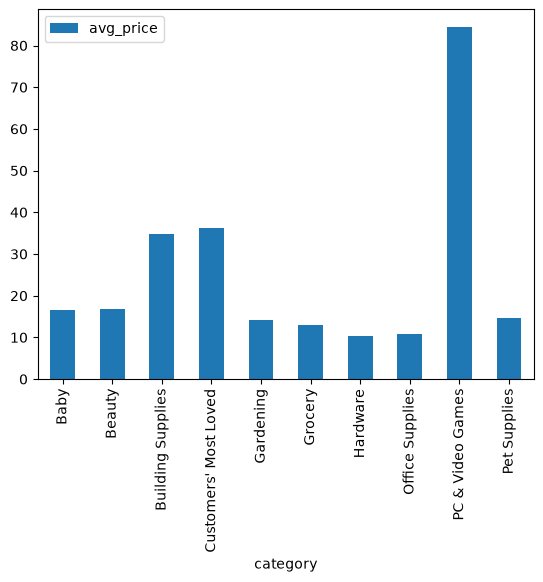

In [111]:
df_b.plot(kind="bar", stacked=True);

**3. Box Plots:**

- Visualize the distribution of product ratings based on their category using side-by-side box plots. Filter out the top 10 categories based on count for better visualization.
- Which category tends to receive the highest median rating from customers? Don't filter here by top categories.

In [112]:
rating_df = df_best_selled_categories[df_best_selled_categories["category"].isin(top_10_categories)]
rating_df

,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
2230292,B086CP6F43,Me to You Tatty Teddy with Happy Birthday Glas...,4.7,195,9.99,notTheBest,50,Baby
2230044,B0B25R43YV,Curlimals Blue The Badger Interactive Soft Toy...,4.5,167,19.99,notTheBest,50,Baby
2230009,B07XT4521Y,Baby Changing Bag Diaper Nappy Rucksack Backpa...,4.6,346,29.86,notTheBest,100,Baby
2229977,B00712NYP8,Maple Blocks Kids Wooden Building Blocks by Ha...,4.6,2827,15.99,notTheBest,50,Baby
2229880,B099K9XLLB,Nuby Penguin Baby Play Mat – Baby Toy Activity...,4.7,384,39.99,notTheBest,100,Baby
...,...,...,...,...,...,...,...,...
25195,B09429MVWX,ZISMA Double Sided Sticky Pads 50 Pcs Heavy Du...,4.3,4460,5.99,notTheBest,3000,Hardware
25189,B09KTDPWLV,6 Rolls - Cellotape Strong Clear Packing Tape ...,4.5,1440,2.25,notTheBest,3000,Hardware
25170,B08L56ZR4P,Twin Pack Premium Masking Tape - 50 Metre Roll...,4.4,5147,4.99,notTheBest,5000,Hardware
25167,B005FEGYCO,"LE LED Torch Battery Powered, LE1000 Super Bri...",4.6,31119,6.99,theBest,0,Hardware


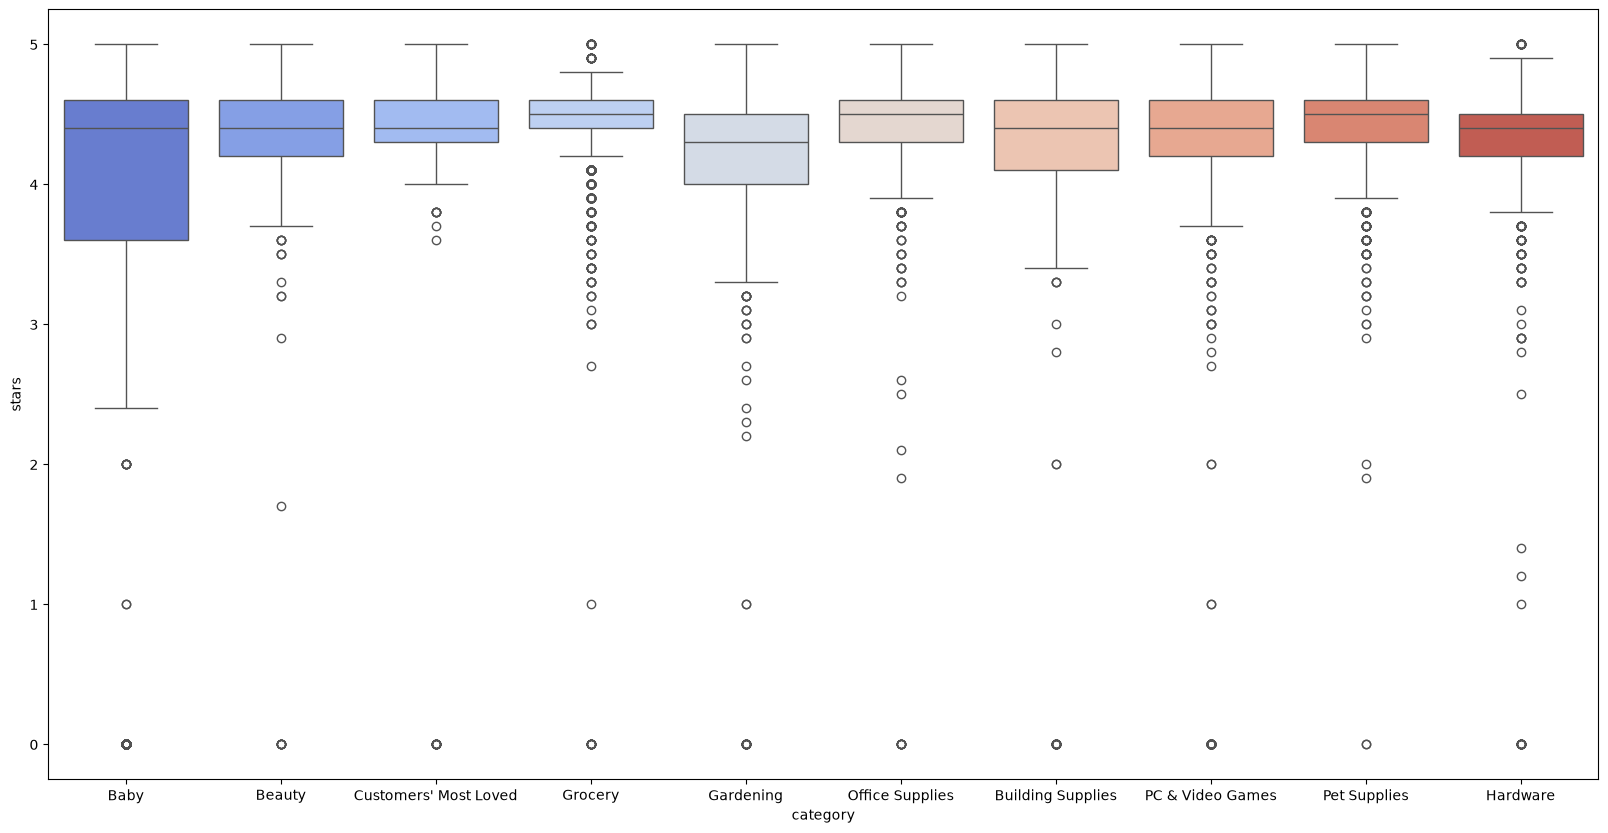

In [117]:
plt.figure(figsize=(20, 10))
sns.boxplot(data = rating_df, x='category', y='stars', palette="coolwarm", hue='category', legend=False);

## Part 3: Investigating the Interplay Between Product Prices and Ratings

**Objective:** Analyze how product ratings (stars) correlate with product prices.

**1. Correlation Coefficients:**

- Calculate the correlation coefficient between price and stars.
- Is there a significant correlation between product price and its rating?

In [121]:
pearson_corr_coef = filtered_price["price"].corr(filtered_price["stars"])
abs(pearson_corr_coef)

np.float64(0.09842525447416375)

In [122]:
spearman_corr_coef = filtered_price["price"].corr(filtered_price["stars"], method='spearman')
abs(spearman_corr_coef)

np.float64(0.10476880404853645)

**Conclusion.**
Both methods of correlation coefficient calculation gives us very small, practically 0 correlation between product price and rating

**2. Visualizations:**

- Use a scatter plot to visualize the relationship between product rating and price. What patterns can you observe?
- Use a correlation heatmap to visualize correlations between all numerical variables.
- Examine if product prices typically follow a normal distribution using a QQ plot.

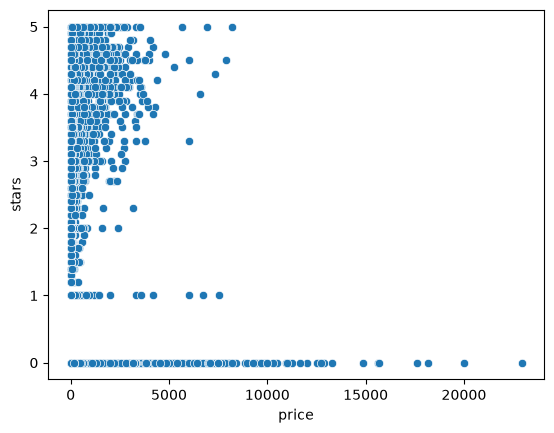

In [123]:
sns.scatterplot(data=filtered_price, x='price', y='stars');

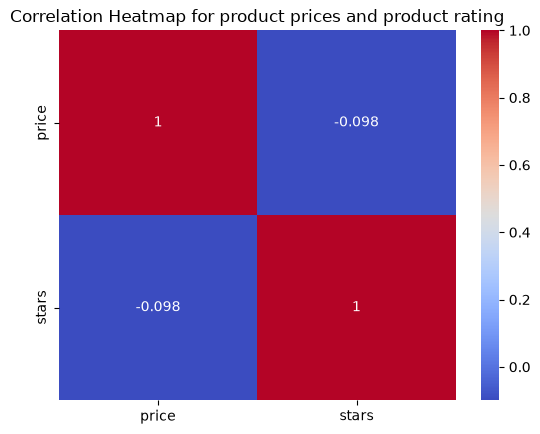

In [129]:
corr_matrix = filtered_price[["price", "stars"]].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap for product prices and product rating")
plt.show()

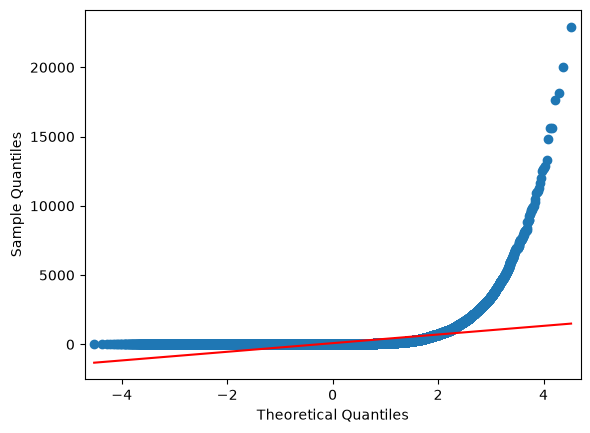

In [132]:
sm.qqplot(filtered_price['price'], line='s');

**Submission:** Submit a Jupyter Notebook which contains code and a business-centric report summarizing your findings.

**Bonus:**

- Do the same analysis without taking out the outliers. What are your insights?

In [133]:
df

,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,notTheBest,0,Hi-Fi Speakers
1,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,theBest,0,Hi-Fi Speakers
2,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,notTheBest,0,Hi-Fi Speakers
3,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,notTheBest,0,Hi-Fi Speakers
4,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,notTheBest,0,Hi-Fi Speakers
...,...,...,...,...,...,...,...,...
2443646,B0CHSD7P2Q,"Motorbike Armour, Motorbike Clothing, Cycling ...",0.0,0,22.34,notTheBest,0,Motorbike Clothing
2443647,B0B7B8FNBQ,PROFIRST Waterproof Motorcycle 2 Piece Ladies ...,0.0,0,97.99,notTheBest,0,Motorbike Clothing
2443648,B0BD5FL5FB,Men’s Motorcycle Motorbike Biker Trousers Kevl...,0.0,0,52.99,notTheBest,0,Motorbike Clothing
2443649,B008OYLL4I,Texpeed Mens Motorcycle Motorbike Biker Trouse...,4.3,404,79.99,notTheBest,0,Motorbike Clothing


In [134]:
df_best_selled_categories_with_outliers = df[(df["category"].isin(sorted_crosstable.index))]
list_top20_category_with_outliers = df_best_selled_categories_with_outliers["category"].value_counts().head(20).index
list_top20_category_with_outliers

Index(['Beauty', 'Women', 'Baby', 'Storage & Organisation',
       'Health & Personal Care', 'Grocery', 'Arts & Crafts', 'Pet Supplies',
       'Gardening', 'Office Supplies', 'Power & Hand Tools', 'Hardware',
       'Agricultural Equipment & Supplies', 'Building Supplies',
       'Large Appliances', 'Customers' Most Loved', 'PC & Video Games',
       'Women's Sports & Outdoor Shoes', 'Luxury Food & Drink',
       'Motorbike Clothing'],
      dtype='str', name='category')

In [135]:
plot_df_with_outliers = df_best_selled_categories_with_outliers[df_best_selled_categories_with_outliers["category"].isin(list_top20_category_with_outliers)]
plot_df_with_outliers

,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
18446,B004NVU8TK,Texpeed Mens All Black Waterproof Armoured Mot...,4.4,4151,59.99,theBest,0,Motorbike Clothing
18447,B07LGYG429,HWK Dual Sport Motorcycle Pants for Men with W...,4.5,1053,37.61,notTheBest,0,Motorbike Clothing
18448,B08663VN8N,Genuine Triumph Motorcycles Jack Neck Tube,4.8,209,24.99,notTheBest,0,Motorbike Clothing
18449,B08THPMZ5N,Zorax Hi-vis Yellow/Black Waterproof Windproof...,4.2,198,34.98,notTheBest,0,Motorbike Clothing
18450,B074ZN6XN9,"COFIT Motorcycle Gloves for Men and Women, Ful...",4.3,36418,16.99,theBest,100,Motorbike Clothing
...,...,...,...,...,...,...,...,...
2443646,B0CHSD7P2Q,"Motorbike Armour, Motorbike Clothing, Cycling ...",0.0,0,22.34,notTheBest,0,Motorbike Clothing
2443647,B0B7B8FNBQ,PROFIRST Waterproof Motorcycle 2 Piece Ladies ...,0.0,0,97.99,notTheBest,0,Motorbike Clothing
2443648,B0BD5FL5FB,Men’s Motorcycle Motorbike Biker Trousers Kevl...,0.0,0,52.99,notTheBest,0,Motorbike Clothing
2443649,B008OYLL4I,Texpeed Mens Motorcycle Motorbike Biker Trouse...,4.3,404,79.99,notTheBest,0,Motorbike Clothing


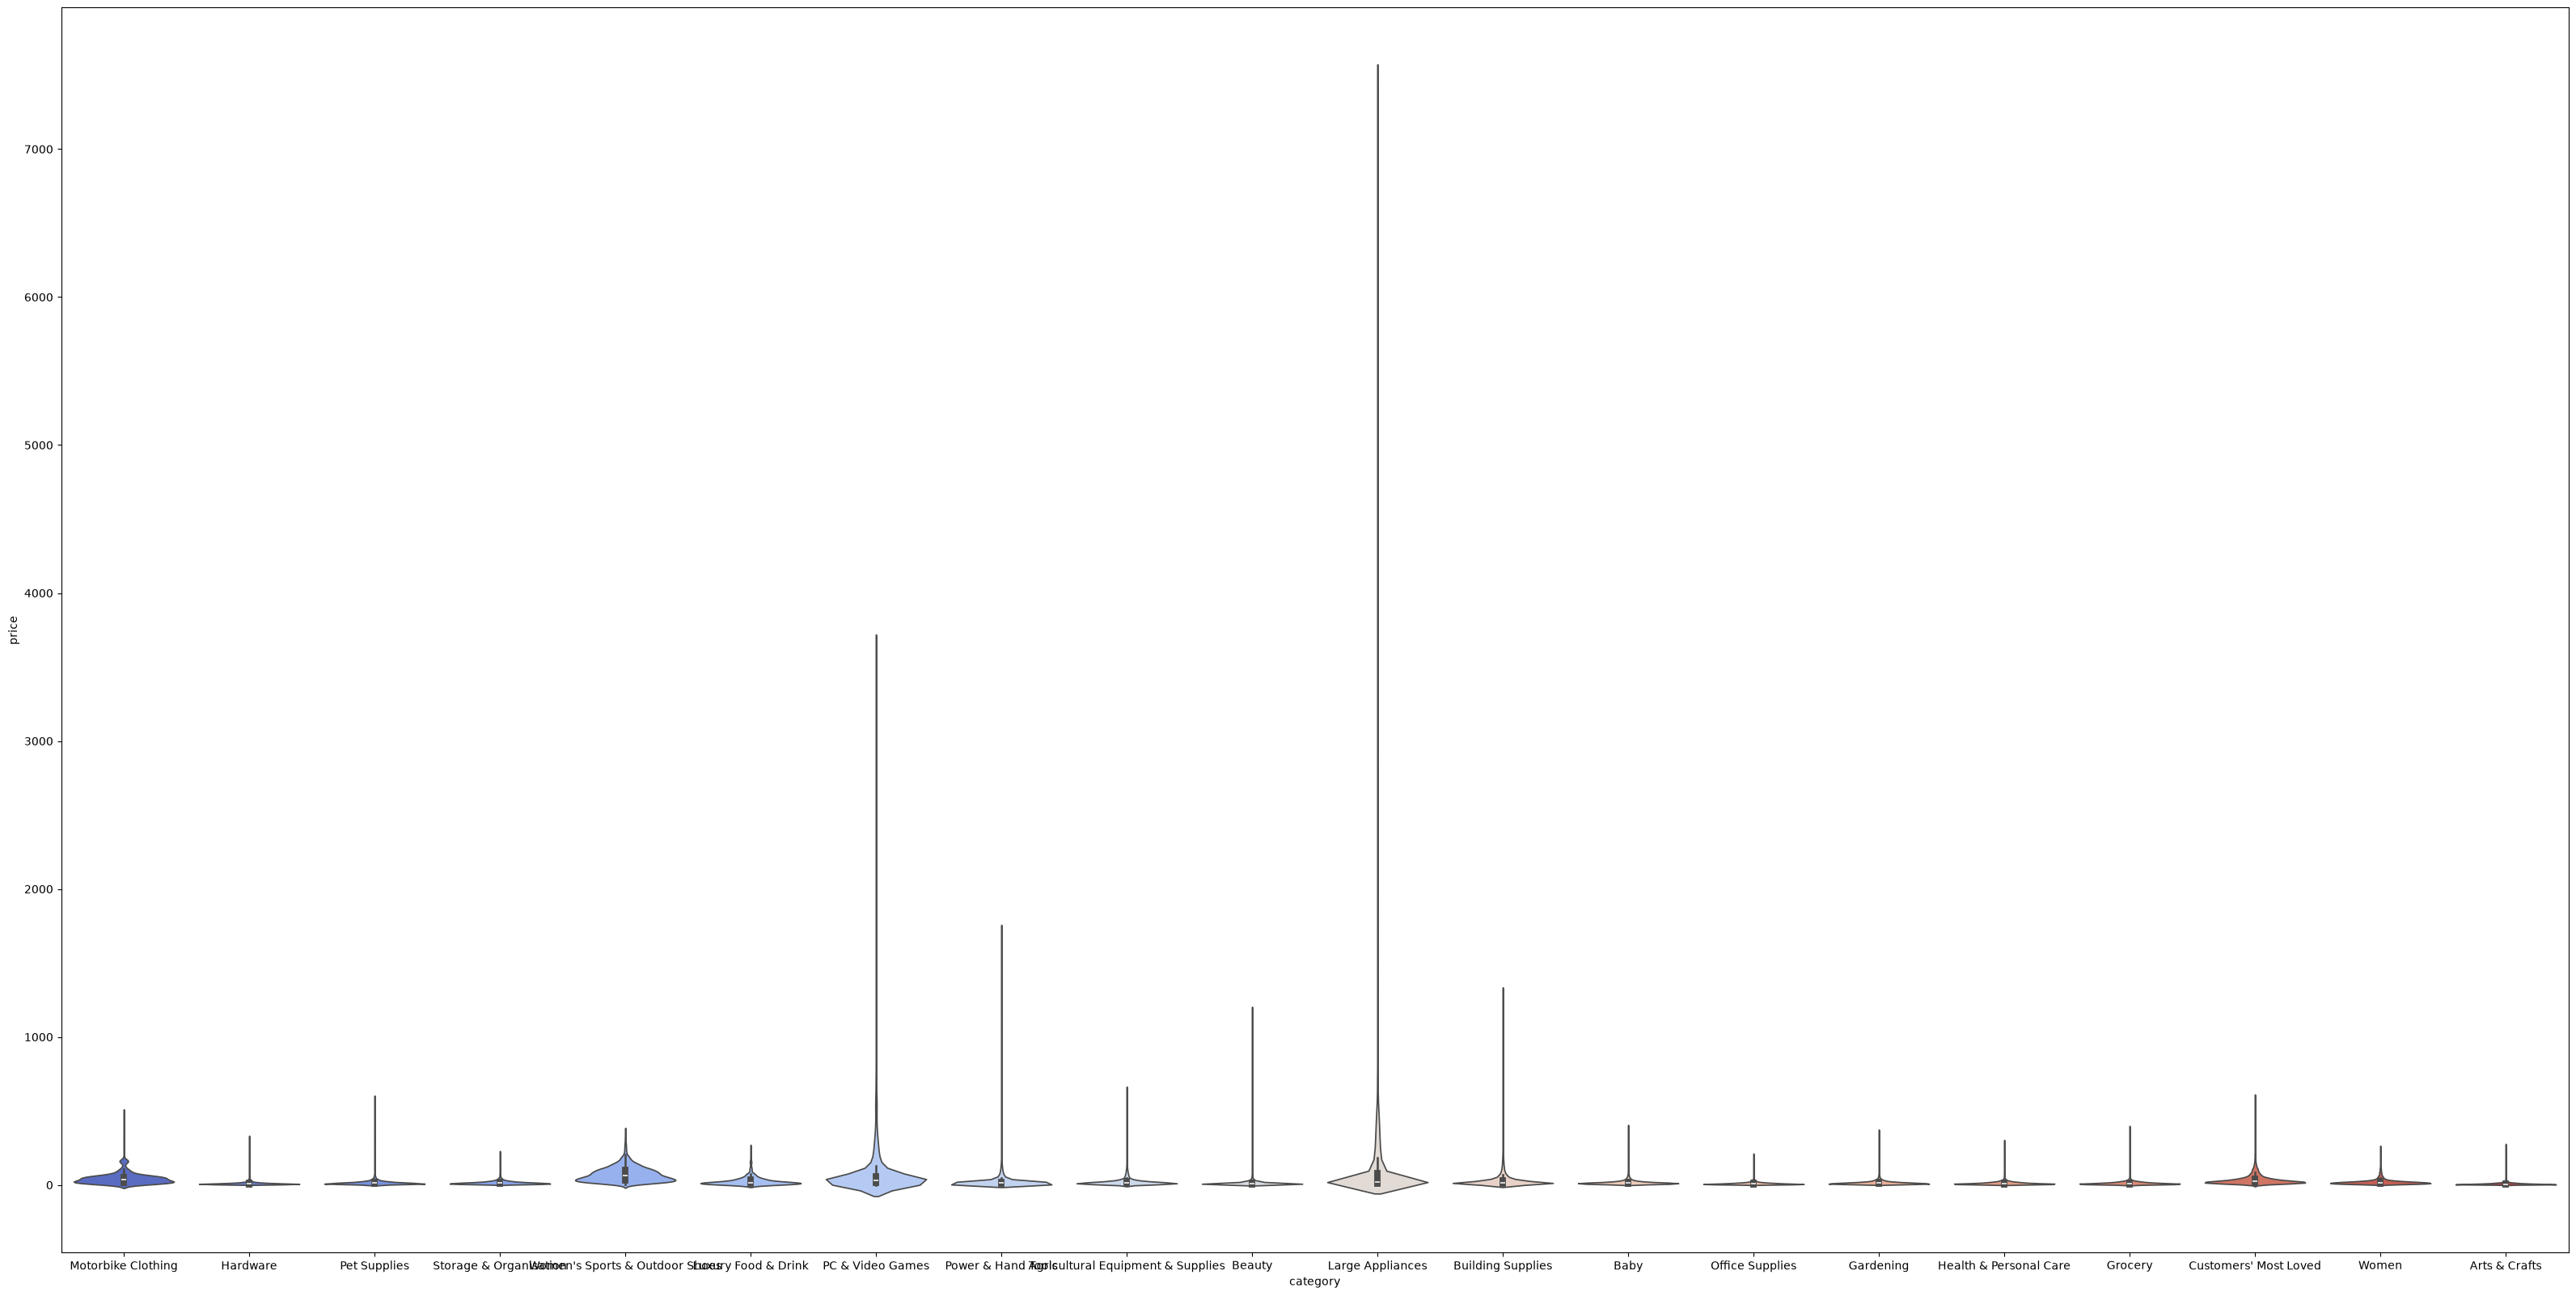

In [136]:
plt.figure(figsize=(40, 20))
sns.violinplot(data=plot_df_with_outliers, x='category', y='price', palette="coolwarm", hue='category', legend=False);

In [137]:
top_10_categories_with_outliers = df_best_selled_categories_with_outliers["category"].value_counts().head(10).index
top_10_categories_with_outliers

Index(['Beauty', 'Women', 'Baby', 'Storage & Organisation',
       'Health & Personal Care', 'Grocery', 'Arts & Crafts', 'Pet Supplies',
       'Gardening', 'Office Supplies'],
      dtype='str', name='category')

In [138]:
df_barchar_out = df_best_selled_categories_with_outliers[df_best_selled_categories_with_outliers["category"].isin(top_10_categories_with_outliers)]
df_b_out = df_barchar_out.groupby(["category"]).agg(avg_price=("price", "mean"))
df_b_out

,avg_price
category,
Arts & Crafts,8.182523
Baby,18.006239
Beauty,13.222322
Gardening,15.652256
Grocery,12.625387
Health & Personal Care,12.821825
Office Supplies,10.554912
Pet Supplies,15.535528
Storage & Organisation,15.883500


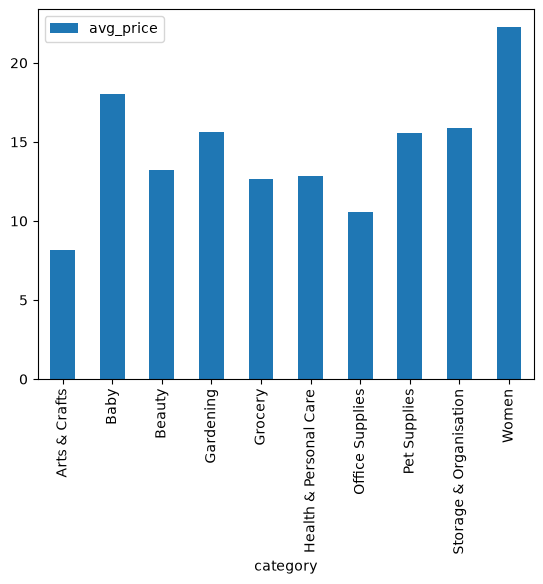

In [139]:
df_b_out.plot(kind="bar", stacked=True);

In [140]:
rating_df_out = df_best_selled_categories_with_outliers[df_best_selled_categories_with_outliers["category"].isin(top_10_categories_with_outliers)]
rating_df_out

,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
208322,B001MZV3OO,Catsan Hygiene Cat Litter 20L,4.7,31204,14.99,notTheBest,50000,Pet Supplies
208323,B00BSYR7K8,"Earth Rated Dog Poo Bags, New Look, Guaranteed...",4.7,129459,13.74,theBest,20000,Pet Supplies
208324,B002ALISWY,"Johnsons 4Fleas Tablets for Cats and Kittens, ...",4.4,11737,7.95,notTheBest,10000,Pet Supplies
208325,B00BEXP5MA,Protexin Veterinary Pro-Fibre for Dogs and Cat...,4.6,6959,13.33,theBest,10000,Pet Supplies
208326,B082VLVSTT,Pedigree Schmackos Mega Pack 110 Strips Snacks...,4.8,19897,6.50,theBest,10000,Pet Supplies
...,...,...,...,...,...,...,...,...
2232325,B0BNL6PGHW,"MAELOVE 25cm Plush Toy, Durable Soft Toy, Game...",4.2,11,10.99,notTheBest,0,Baby
2232326,B0BLHMDK1Z,My Babiie iSize Quilted Black Isofix Booster C...,4.8,16,39.99,notTheBest,0,Baby
2232327,B075Z2HPPZ,Simple Joys by Carter's Baby Girls' Cotton Foo...,4.6,6853,30.30,notTheBest,50,Baby
2232328,B0C7BR3KK1,"Monster Plush Toys,My Emotional Little Monster...",4.5,5,7.99,notTheBest,50,Baby


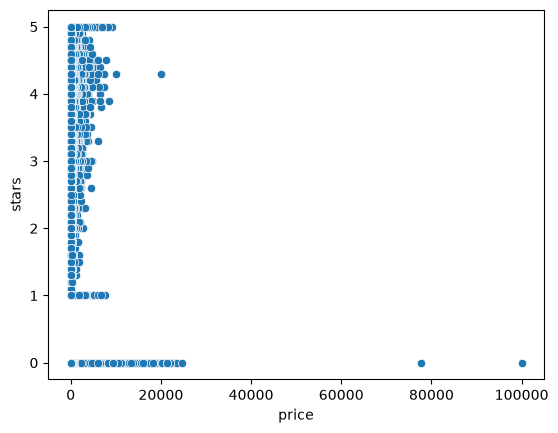

In [141]:
sns.scatterplot(data=df, x='price', y='stars');

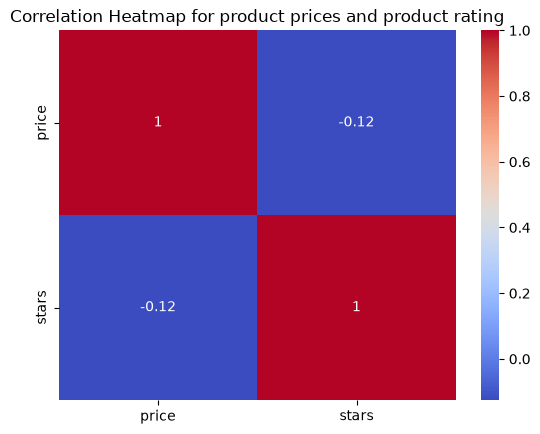

In [142]:
corr_matrix_out = df[["price", "stars"]].corr()
sns.heatmap(corr_matrix_out, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap for product prices and product rating")
plt.show()

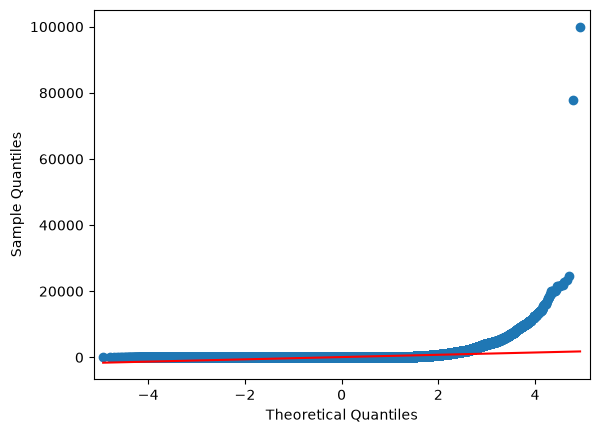

In [143]:
sm.qqplot(df['price'], line='s');